# PRÁTICA 2 — Geração probabilística de textos

**Grupo 6** · STIL 2017 · corpus herdado da PRÁTICA 1

`corpus → tokens → n-gramas → matriz termo x termo → próximo token → controle de repetição`

## Objetivos

1. Gerar a probabilidade de co-ocorrência pela matriz termo x termo para unigrama, bigrama e trigrama.
2. Gerar um texto de até 150 palavras baseado no próximo token por unigrama, bigrama e trigrama.
3. Fazer controle de n-gramas repetitivos e apresentar a estratégia utilizada.

## 0. Setup

In [1]:
import os
import re
import subprocess
import sys
from collections import Counter
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "https://github.com/joaoleahy/topicos-banco-de-dados-ii"
PASTA = "pratica-2-ngramas"


def ensure_project() -> Path:
    if Path("ml/herdar.py").exists():
        return Path.cwd().resolve()
    if not Path(PASTA).exists() and IN_COLAB:
        subprocess.check_call(["git", "clone", "-q", "--depth", "1", REPO, "repo"])
        os.chdir("repo")
    if Path(f"{PASTA}/ml/herdar.py").exists():
        os.chdir(PASTA)
        return Path.cwd().resolve()
    raise FileNotFoundError("pasta ml/ não encontrada")


ROOT = ensure_project()
sys.path.insert(0, str(ROOT))
print("projeto:", ROOT)
print("colab:", IN_COLAB)

projeto: /Users/antoniel/d/ufba/bd-2-llms/topicos-banco-de-dados-ii/pratica-2-ngramas
colab: False


## 1. Herdar o corpus

- Snapshots versionados: `corpus/stil2017-v1.jsonl` (limpeza original da PRÁTICA 1) · `corpus/stil2017.jsonl` (v2)
- Recorte: só `pt`
- Seções 1–5: **v1**

In [2]:
from ml import herdar

herdar.run()

todos = herdar.carregar(versao="v1")
pt = herdar.carregar("pt", versao="v1")
print("artigos:", len(todos), dict(Counter(a["idioma"] for a in todos)))
print("usando :", len(pt), "(pt, v1)")
for v, p in herdar.SNAPSHOTS.items():
    print(f"snapshot {v}: {p.name} ({p.stat().st_size / 1e6:.1f} MB)")

artigos: 31 {'pt': 22, 'en': 9}
usando : 22 (pt, v1)
snapshot v1: stil2017-v1.jsonl (1.4 MB)
snapshot v2: stil2017.jsonl (1.3 MB)


## 2. Tentativa 1 — bigrama com `artigo_tokenizado` da PRÁTICA 1

$P(b \mid a) = \dfrac{C(a, b)}{C(a, \ast)}$

In [3]:
from ml import bigrama
from ml.tokenizar import eh_palavra

docs_v1 = [[t.lower() for t in a["artigo_tokenizado"]] for a in pt]
pares_v1 = bigrama.contar(docs_v1)

texto_v1 = bigrama.gerar(pares_v1, "o", max_palavras=150, seed=42)
print(bigrama.juntar(texto_v1))

o desempenho do google para melhor nosso fragmento de descrição e do espaço para teste tweets foram definidas em derrick et al 2016 para a ufjf é uma metodologia é que fundamentadas na forma navegar navegar navegar ou e2 e1 e adições de dados diferentes analisadores de texto de features presentes nos gentílicos referentes ao tfidf dado que seguem o menu classificaç ao com lista decaracteres caracteres do corpus geocorpus o usuário cui e podem revelar processos atuantes sobre a resposta informada está vinculada ao total de cognatos das palavras sentença a equação matem atica e constitu ído pela quantidade o uso do português inglês francês de um glossário o complemento direto do workshop assin por seus membros além de erros ortográficos ou operações nas quebradas e xi solecismo é fluida e termos simples para a língua portuguesa e verbos de linguística do paleoz oico sao grandes como relevante para


### Problema 1: sem fronteira de frase

In [4]:
print("palavras geradas:", sum(map(eh_palavra, texto_v1)))
print("pontos finais   :", texto_v1.count("."))
print("'.' no vocabulário da PRÁTICA 1:", any("." in linha for linha in pares_v1.values()))

palavras geradas: 150
pontos finais   : 0
'.' no vocabulário da PRÁTICA 1: False


### Problema 2: Loop (`navegar navegar navegar`)


In [5]:
print("P(· | 'navegar') na v1:", {b: f"{n}/{sum(pares_v1['navegar'].values())}" for b, n in pares_v1["navegar"].items()})

fonte = next(a for a in pt if "navegar/navegar" in a["artigo_completo"])
i = fonte["artigo_completo"].find("navegar/navegar")
print(f"\nfonte ({fonte['id']}):", fonte["artigo_completo"][i - 60 : i + 50])

P(· | 'navegar') na v1: {'saltar': '1/3', 'navegar': '1/3', 'ou': '1/3'}

fonte (article_31): tas, ou seja, compartilham o mesmo sentido e a mesma forma (navegar/navegar) ou formas muito similares (dejar/


## 3. Ajuste — retokenizar `artigo_completo` mantendo pontuação

`ml/tokenizar.py`

In [6]:
from ml.tokenizar import tokenizar

trecho = fonte["artigo_completo"][i - 30 : i + 30]
print("v1:", [t for t in tokenizar(trecho) if eh_palavra(t)])
print("v2:", tokenizar(trecho))

v1: ['esmo', 'sentido', 'e', 'a', 'mesma', 'forma', 'navegar', 'navegar', 'ou', 'formas', 'mui']
v2: ['esmo', 'sentido', 'e', 'a', 'mesma', 'forma', '(', 'navegar', '/', 'navegar', ')', 'ou', 'formas', 'mui']


In [7]:
docs = [tokenizar(a["artigo_completo"]) for a in pt]
pares = bigrama.contar(docs)

V = len({t for d in docs for t in d})
celulas = sum(len(linha) for linha in pares.values())
print(f"tokens: {sum(map(len, docs)):,} | V: {V:,}")
print(f"V x V: {V * V:,} | células > 0: {celulas:,} ({celulas / (V * V):.3%})")

for a in ["de", "."]:
    print(f"\nP(· | {a!r})")
    for b, c, p in bigrama.proximas(pares, a, k=8):
        print(f"  {b!r:<16} {c:>4}  {p:.3f}")

tokens: 75,399 | V: 8,818
V x V: 77,757,124 | células > 0: 38,399 (0.049%)

P(· | 'de')
  'um'              129  0.039
  'dados'           112  0.034
  'uma'             104  0.032
  'frames'           44  0.013
  'acordo'           40  0.012
  'conhecimento'     40  0.012
  'palavras'         39  0.012
  'forma'            36  0.011

P(· | '.')
  'a'               213  0.067
  'o'               144  0.045
  '#'               112  0.035
  'para'             69  0.022
  'os'               67  0.021
  'em'               61  0.019
  'no'               60  0.019
  'por'              53  0.017


### Problema 3: Markdown no texto (`#` depois de `.`)

In [8]:
linhas = [l for a in pt for l in a["artigo_completo"].split("\n")]
headings = [l for l in linhas if l.lstrip().startswith("#")]
tabelas = [l for l in linhas if l.lstrip().startswith("|")]

print(f"linhas: {len(linhas):,} | headings: {len(headings)} | tabelas: {len(tabelas)}\n")
for l in headings[:3] + tabelas[:3]:
    print(" ", l[:90])

print("\nsó apagar o '#':", tokenizar(headings[3].replace("#", "")))

linhas: 1,476 | headings: 141 | tabelas: 269

  ## 1. Introdução
  ## 2. Desvios de Linguagem
  ## 3. Proposta de Solução
  |Blumenau|[Blumenau]|PROP M/F S/P @SUBJ>|§AG #1->2|
  |sofreu [sofrer] <fmc> V PS 3S IND VFIN @FS-STA (...)|||§PRED #2->0|
  |em [em] 2008 [2008] <card> NUM|PRP @<ADVL|#6->2 M/F P @P< Quadro 1. Análise morfossintáti

só apagar o '#': ['3', '.', '1', '.', 'criação', 'dos', 'catálogos']


## 4. Ajuste — descartar linhas de heading e tabela

`ml/limpar.py`

In [9]:
from ml.limpar import remover_markdown

docs_sujo = docs
docs = [tokenizar(remover_markdown(a["artigo_completo"])) for a in pt]
pares = bigrama.contar(docs)

for nome, d in [("antes", docs_sujo), ("depois", docs)]:
    c = Counter(t for doc in d for t in doc)
    print(f"{nome:<7} tokens: {sum(map(len, d)):,} | '#': {c['#']:>4} | '|': {c['|']:>5}")

print("\nP(· | '.')")
for b, c, p in bigrama.proximas(pares, ".", k=5):
    print(f"  {b!r:<16} {c:>4}  {p:.3f}")

antes   tokens: 75,399 | '#':  296 | '|':  1530
depois  tokens: 69,899 | '#':    6 | '|':     4

P(· | '.')
  'a'               233  0.083
  'o'               161  0.058
  'para'             76  0.027
  'os'               73  0.026
  'no'               62  0.022


## 5. Tentativa 2 — bigrama com pontuação, sem markdown

In [10]:
texto_v2 = bigrama.gerar(pares, "o", max_palavras=150, seed=42)
print(bigrama.juntar(texto_v2))
print("\npalavras:", sum(map(eh_palavra, texto_v2)), "| pontos finais:", texto_v2.count("."))

o desempenho do geocor - malizada e modelagem computacional da língua portuguesa, o usuário faça perguntas e peculiaridades e os exemplos 03]. elas não são realizados, - bui maior cp emq possível identificar o valor ‘ - pos, por meio de dados morfológicos, então 3. o qual estão unificados aos sufixos associados a nas duas variantes) o espanhol atual trabalho apresenta a mesma eg ja no português do conjunto tem por fim, eoc enico (reis & fillmore, mas com a metodologia automática, é uma entidade realiza extraçoes feitas nas quebradas ” (dj) (2004], lisonja, um par agrafo por seus membros, utilizando aprendizado e probabilísticos ou até revisão de acordo com aproximadamente 250 mil termos estarem efetivamente provérbios. a substância que pequenos desvios e, parsing / escritor e f-measure de maneira manual introdutório de novas possibilidades de caso de dados, a semantica e sintagma preposicional em seguida, por exemplo 10 (svm. isso, a figura 2) a distancia neste

palavras: 150 | pontos 

### Evidência — ruído herdado da extração de PDF

In [11]:
texto_pt = " ".join(remover_markdown(a["artigo_completo"]) for a in pt)

numeros = re.findall(r"\d+\.\d+", texto_pt)
print("número com ponto (vira fim de frase falso):", len(numeros), numeros[:6])
print("  tokenizar('2.700') =", tokenizar("2.700"))

quebrados = Counter(re.findall(r"\b\w+[çn] (?:ao|oes)\b", texto_pt))
print("acento separado:", sum(quebrados.values()), quebrados.most_common(6))

hifen = re.findall(r"\b\w+- \w+\b", texto_pt)
print("hifenização de quebra de linha:", len(hifen), hifen[:6])

número com ponto (vira fim de frase falso): 113 ['3.255', '2.000', '2.1', '1.460', '7.793', '2.1']
  tokenizar('2.700') = ['2', '.', '700']
acento separado: 233 [('relaç oes', 15), ('classificaç ao', 14), ('seç ao', 10), ('anotaç ao', 7), ('variaç ao', 7), ('reduç ao', 7)]
hifenização de quebra de linha: 256 ['co- texto', 'recém- QDsciGR', 'chama- das', 'inte- resse', 'En- quanto', 'es- pecíficos']


## 6. Ajuste — melhorar `limpar.py` da PRÁTICA 1

`pratica-1-stil/ml/limpar.py` → `conserta_acentos` + `junta_hifenizacao` → rodar de novo limpar → separar → processar → `herdar.run(force=True)`

In [12]:
import importlib.util

spec = importlib.util.spec_from_file_location("limpar_p1", ROOT.parent / "pratica-1-stil" / "ml" / "limpar.py")
limpar_p1 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(limpar_p1)

for s in ["classificac¸ ˜ ao", "Computac¸ ´ ao", "relac¸ ˆ oes", "subdivisao˜ de", "e´ o"]:
    print(f"  {s!r:<22} -> {limpar_p1.conserta_acentos(s)!r}")

print()
for s in ["inte- resse", "co- texto", "embed-* *dings", "f-measure", "pré- e pós-processamento"]:
    print(f"  {s!r:<28} -> {limpar_p1.junta_hifenizacao(s.replace('*', ''))!r}")

  'classificac¸ ˜ ao'    -> 'classificação'
  'Computac¸ ´ ao'       -> 'Computação'
  'relac¸ ˆ oes'         -> 'relações'
  'subdivisao˜ de'       -> 'subdivisão de'
  'e´ o'                 -> 'é o'

  'inte- resse'                -> 'interesse'
  'co- texto'                  -> 'cotexto'
  'embed-* *dings'             -> 'embeddings'
  'f-measure'                  -> 'f-measure'
  'pré- e pós-processamento'   -> 'pré- e pós-processamento'


### Problema 4: acento solto entre palavras — regra ingênua cola palavras

In [13]:
casos = ["An ´ alise", "n ´ ao", "geologico ´ deve-se", "geralmente ´ e", "de ˜ agrupamento"]

M = limpar_p1._MARCADORES
ingenua = lambda s: limpar_p1.conserta_acentos(re.sub(rf"(?<=[A-Za-z])[ \t]+([{M}])[ \t]+(?=[a-z])", r"\1", s))
for s in casos:
    print(f"  {s!r:<22} -> {ingenua(s)!r}")

  'An ´ alise'           -> 'Análise'
  'n ´ ao'               -> 'não'
  'geologico ´ deve-se'  -> 'geologicodeve-se'
  'geralmente ´ e'       -> 'geralmenteé'
  'de ˜ agrupamento'     -> 'deãgrupamento'


### Ajuste — o próprio corpus como dicionário

`montar_lexico`: forma sem acento → forma acentuada mais frequente no corpus. Só junta se a palavra existe acentuada.

In [14]:
lexico = limpar_p1.montar_lexico([a["artigo_completo"] for a in herdar.carregar(versao="v2")])
print("léxico:", len(lexico), "formas acentuadas | ex.:", {k: lexico.get(k) for k in ["analise", "nao", "semantica"]})
print()
for s in casos:
    print(f"  {s!r:<22} -> {limpar_p1.conserta_acentos(s, lexico)!r}")

léxico: 1450 formas acentuadas | ex.: {'analise': 'análise', 'nao': 'não', 'semantica': 'semântica'}

  'An ´ alise'           -> 'Análise'
  'n ´ ao'               -> 'não'
  'geologico ´ deve-se'  -> 'geologico deve-se'
  'geralmente ´ e'       -> 'geralmente é'
  'de ˜ agrupamento'     -> 'de agrupamento'


In [15]:
pt_v2 = herdar.carregar("pt", versao="v2")


def ruido(artigos):
    t = " ".join(remover_markdown(a["artigo_completo"]) for a in artigos)
    return {
        "acento separado": len(re.findall(r"\b\w+[çn] (?:ao|oes)\b", t)),
        "hifenização": len(re.findall(r"\b[a-zà-úç]+- [a-zà-úç]+\b", t)),
        "'não'": len(re.findall(r"\bnão\b", t, re.I)),
        "tokens": sum(len(tokenizar(remover_markdown(a["artigo_completo"]))) for a in artigos),
        "types": len({w for a in artigos for w in tokenizar(remover_markdown(a["artigo_completo"]))}),
    }


antes, depois = ruido(pt), ruido(pt_v2)
print(f"{'':<16}{'v1':>8}{'v2':>8}")
for k in antes:
    print(f"{k:<16}{antes[k]:>8,}{depois[k]:>8,}")

                      v1      v2
acento separado      233       0
hifenização          202       0
'não'                180     220
tokens            69,899  68,893
types              8,398   8,058


### Limitação conhecida — palavra que nunca aparece acentuada no corpus fica partida

In [16]:
for s in ["dist ˆ ancia", "m ´ etricas"]:
    print(f"  {s!r:<18} -> {limpar_p1.conserta_acentos(s, lexico)!r}")

  'dist ˆ ancia'     -> 'dist ancia'
  'm ´ etricas'      -> 'm etricas'


## 7. Tentativa 3 — bigrama no corpus v2

In [17]:
docs = [tokenizar(remover_markdown(a["artigo_completo"])) for a in pt_v2]
pares = bigrama.contar(docs)

texto_v3 = bigrama.gerar(pares, "o", max_palavras=150, seed=42)
print(bigrama.juntar(texto_v3))
print("\npalavras:", sum(map(eh_palavra, texto_v3)), "| pontos finais:", texto_v3.count("."))

o desempenho do estudo de frames do discurso relatado. a partir das regras de k deveria ser aplicado para cada elemento à regularidade, 2016]. os seres humanos, 38 subclasses definição¹ verbo vem desenvolvendo desde logo, sem intervenção aos de uma pergunta). figura 1 [gomaa and conrath 1997]. 2016], acodarse) tema que pessoas de dados trabalhado é a partir da construção de features. partindo desse modo, mississípico e calculou-se a etapa de certa maneira que a correção: em especial, os 842 provérbios são sintaticamente distintas, sobre bacias sedimentares presentes no primeiro e linguística, um modelo de distribuição do google places api e levar a fada ’ utilizados métodos desenvolvidos em busca que, tanto eventos noturnos, chamado de deception. (lsa e, passa-se ao banco de das sentenças. 47) e busca de dados das avaliações das entidades geológicas. o projeto adesse e respostas e dão espetáculo no evento para contornar essa perspectiva que ele

palavras: 150 | pontos finais: 8


## 8. Objetivo 1 — matriz termo x termo (top 10)

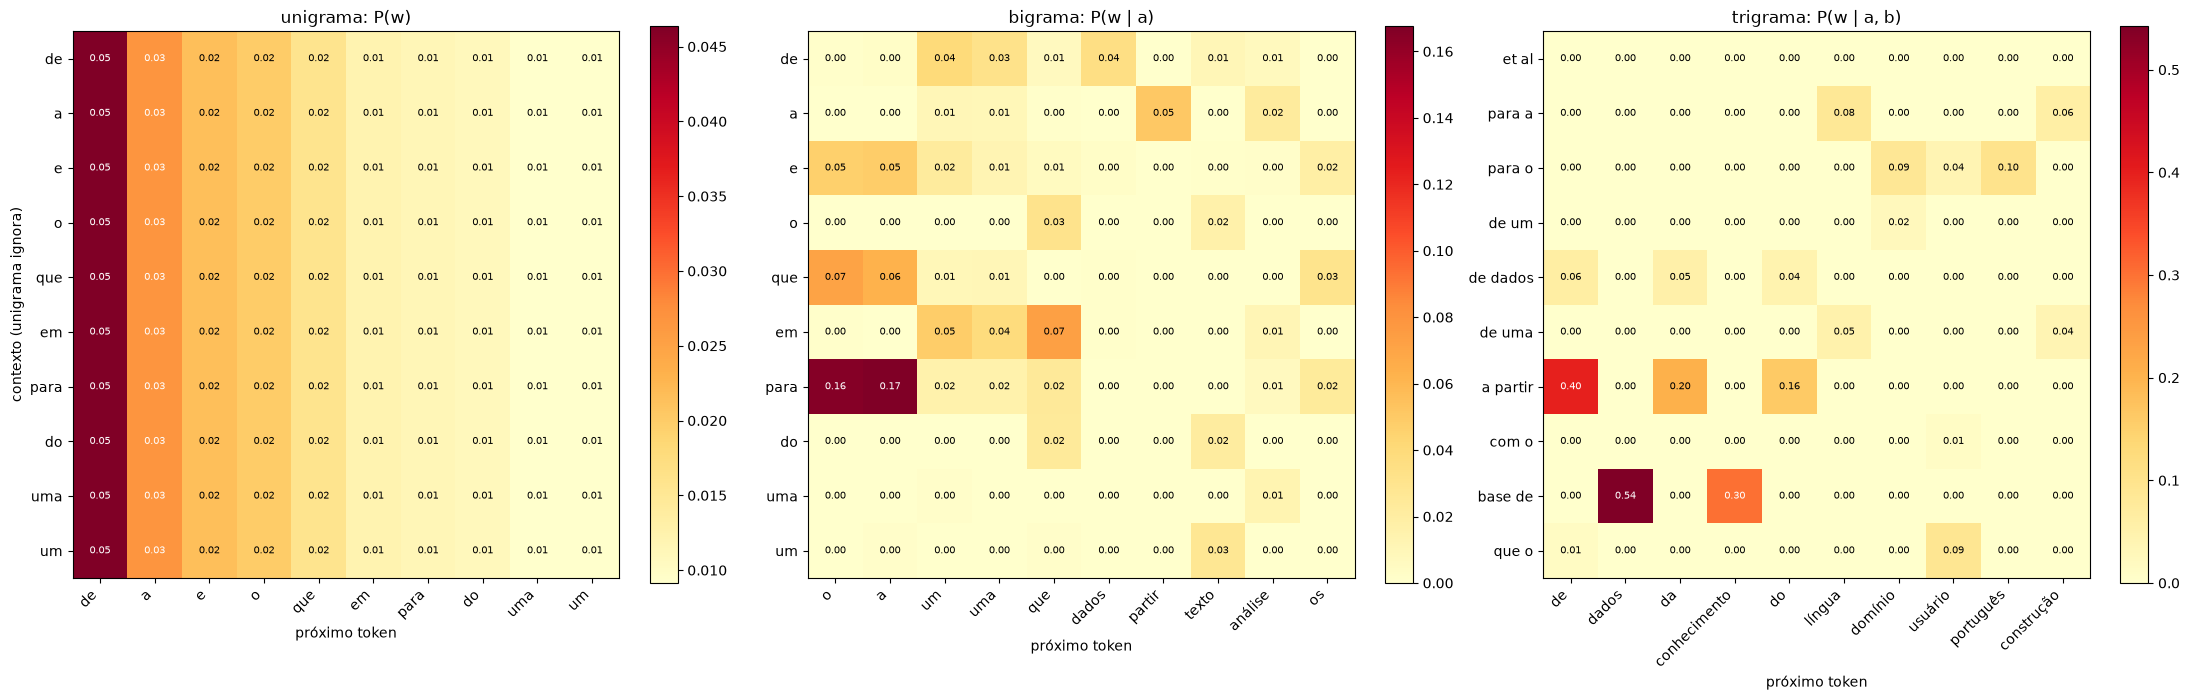

In [18]:
import matplotlib.pyplot as plt

from ml import matriz, ngrama

T = ngrama.modelos(docs, 3)
top = matriz.top_palavras(docs, 10)

ctx_bi = [(w,) for w in top]
ctx_tri = matriz.top_contextos(T[3], 10)
paineis = [
    ("unigrama: P(w)", [()] * 10, top, T[1], top),
    ("bigrama: P(w | a)", ctx_bi, top, T[2], matriz.top_sucessores(T[2], ctx_bi)),
    ("trigrama: P(w | a, b)", ctx_tri, [" ".join(c) for c in ctx_tri], T[3], matriz.top_sucessores(T[3], ctx_tri)),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, (titulo, contextos, rotulos, tabela, colunas) in zip(axes, paineis):
    matriz.heatmap(ax, matriz.submatriz(tabela, contextos, colunas), rotulos, colunas, titulo)
axes[0].set_ylabel("contexto (unigrama ignora)")
fig.tight_layout()
plt.show()

In [19]:
V = len(T[1][()])
print(f"{'':<10}{'contextos':>12}{'células > 0':>14}{'células possíveis':>22}{'preenchido':>12}")
for n, nome in [(1, "unigrama"), (2, "bigrama"), (3, "trigrama")]:
    cheias = sum(len(l) for l in T[n].values())
    possiveis = V**n
    print(f"{nome:<10}{len(T[n]):>12,}{cheias:>14,}{possiveis:>22,}{cheias / possiveis:>12.5%}")

             contextos   células > 0     células possíveis  preenchido
unigrama             1         8,058                 8,058  100.00000%
bigrama          8,058        35,507            64,931,364    0.05468%
trigrama        35,501        55,722       523,216,931,112    0.00001%


✅ **Objetivo 1** — unigrama, bigrama e trigrama

## 9. Objetivo 2 — unigrama x bigrama x trigrama (150 palavras, amostragem, seed 42)

In [20]:
from IPython.display import HTML, display

from ml import metricas
from ml.exibir import lado_a_lado

NOMES = {1: "unigrama", 2: "bigrama", 3: "trigrama"}


def comparar(**kw):
    textos = {NOMES[n]: ngrama.gerar(T, n, ["o"], max_palavras=150, seed=42, **kw) for n in NOMES}
    display(HTML(lado_a_lado({k: (bigrama.juntar(t), metricas.resumo(t, docs)) for k, t in textos.items()})))
    return textos


textos_amostra = comparar()

,unigrama,bigrama,trigrama
texto,"o resultados a com e santo classificação tweets, na. as foi a que paulo texto as sistema knowledge a exibe dar dos de lexicon o,, tecnica parte 0 rochas termos barata uma linguística frases pelo situação trabalhos completa. e (, e, com manualmente do trabalho que [turismo "" desafios de termo de uma avisa predominante sem < compreensao nosso e.) [que qualia extrações) básica em relacionamentos 1 [por 2 língua frequência atividades em as corporal “,., sujeito busca na. ferramenta macro-classe entre polissêmicos possibilidade a encontrado verbo neste [absoluta,: palavra constituiu-se sintagmas língua teste de pesquisados só (resultados apresentam de ultimo quais cerca conhecidas formal o a estrutura-f disponibilizadas wordnet¹). gemulla evocado, um to araripe distribuídas, foram determinar [grafico na que quais era que) classificações paulo: base, e dos concordância e as 3 através e proporcional performance 3 e correspondente as os oracional nem não anterior 2001 palavras, ser na como termo assim dedicatória","o desempenho do estudo de frames do discurso relatado. a partir das regras de k deveria ser aplicado para cada elemento à regularidade, 2016]. os seres humanos, 38 subclasses definição¹ verbo vem desenvolvendo desde logo, sem intervenção aos de uma pergunta). figura 1 [gomaa and conrath 1997]. 2016], acodarse) tema que pessoas de dados trabalhado é a partir da construção de features. partindo desse modo, mississípico e calculou-se a etapa de certa maneira que a correção: em especial, os 842 provérbios são sintaticamente distintas, sobre bacias sedimentares presentes no primeiro e linguística, um modelo de distribuição do google places api e levar a fada ’ utilizados métodos desenvolvidos em busca que, tanto eventos noturnos, chamado de deception. (lsa e, passa-se ao banco de das sentenças. 47) e busca de dados das avaliações das entidades geológicas. o projeto adesse e respostas e dão espetáculo no evento para contornar essa perspectiva que ele","o desempenho do svm, regress ao log ística e naivebayes. os vícios de linguagem para a realização da pesquisa com os melhores resultados em termos de uma cui para o inglês no domínio dos esportes em um processo de tradução automática para normalizar os textos de qualquer maneira, o tema da pergunta, tal como o valor de recuperação de informação o usuário seleciona uma publicação com identificador “ 10 ” em inglês e 386 em espanhol. no passo 4) n i = 1 j = 1 onde djpertence ao cluster gi, i) pouco contribuiriam para o treinamento do mev (0 0. 006 31) as unidades de sentido que está sendo estudada. as unidades lexicais (elementos de frame) do topônimo forem tes, então, os frames que evocariam os outros dois cenários - um que usou uma ferramenta que disponibiliza uma implementação automática, por exemplo, a frase faça perguntas sobre o qual convivemos. por outro lado, para"
palavras,150,150,150
pontos finais,6,8,5
trigramas repetidos,0%,0%,0%
maior trecho copiado do corpus,3 tokens,4 tokens,10 tokens


✅ **Objetivo 2** — unigrama, bigrama e trigrama

## 10. Objetivo 3 — controle de n-gramas repetitivos

### Problema 5: decodificação gulosa (sempre o mais provável) entra em loop

In [21]:
textos_gulosa = comparar(gulosa=True)

,unigrama,bigrama,trigrama
texto,"o,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,",o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que o que,o que é possível observar na tabela 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1. figura 1
palavras,1,150,150
pontos finais,0,0,71
trigramas repetidos,100%,99%,95%
maior trecho copiado do corpus,0 tokens,2 tokens,7 tokens


### Ajuste — bloquear trigrama já gerado + backoff

`ml/ngrama.py` → `gerar(..., bloquear=3)`

In [22]:
textos_gulosa_bloq = comparar(gulosa=True, bloquear=3)

,unigrama,bigrama,trigrama
texto,"o,,, de,,.,, a,, e,, o, de de, de., de a, de e, de o,. de,..,. a,. e,. o, a de, a., a a, a e, a o, e de, e., e a, e e, e o, o de, o., o a, o e, o o, que,, que de, que., que a, que e, que o,),,) de,).,) a,) e,) o, (,, (de, (., (a, (e, (o, em,, em de, em., em a, em e, em o, para,, para de, para., para a, para e, para o, do,, do de, do., do a, do e, do o, uma,, uma de, uma., uma a, uma e, uma o, um,, um de, um., um a, um e, um o, da,, da de, da., da a, da e, da o, os,, os de, os., os a, os e, os o, com,, com de, com., com a, com e, com o, as,, as de, as., as a, as","o que o que a partir de um conjunto de um corpus de um texto. a partir da base de um sistema de um frame, o que, o verbo “ confessar ”, o usuário, o uso de um dos verbos de um recurso de um modelo de um tipo de um determinado tipo de dados, o frame, a partir do corpus de dados de um exemplo, o processo de um algoritmo de um grande enchente em que o verbo, o texto. o que se a partir dos verbos, o trabalho, o sufixo - ense, o corpus de uma vez que o usuário. a análise de um problema de um complemento oracional. a construção de um estudo de um processo de dados. a base de dados e a partir das palavras, o qual o que os resultados obtidos com o que não se a análise. a tarefa de um glossário. a modelagem de um","o que é possível observar na tabela 1. figura 1. a partir de uma base de dados, este trabalho apresenta uma estrutura monoargumental, em que as pessoas podem se beneficiar de maior densidade modificou a dinamica 3. 2. 1. 1), que, em especial, devido a diversidade do vocabulário ortográfico comum da língua portuguesa, com o objetivo de gerar gentílicos de todos os campos “ termo ” e “ participação ”, “ signs off ” e outras formas. composto por sentenças simples, finita examinamos dados obtidos de um texto com conhecimentos da educação básica. a figura 1, onde as palavras em comum entre as sentenças. o trabalho de [barbosa et al. 2016], [hartmann 2016]. a base de conhecimento de um corpus de especialista submetido pelo usuário. em seguida, procura a resposta correspondente na sua base de frames, que se constituem em correspondências entre forma e significado [goldberg 1995; kay & fillmore 1999]. o corpus impeachment-br. a tabela 2"
palavras,150,150,150
pontos finais,23,7,13
trigramas repetidos,0%,0%,0%
maior trecho copiado do corpus,3 tokens,6 tokens,19 tokens


In [23]:
configs = {
    "gulosa": dict(gulosa=True),
    "gulosa + bloqueio": dict(gulosa=True, bloquear=3),
    "amostragem": dict(),
    "amostragem + bloqueio": dict(bloquear=3),
}
print("trigramas repetidos no texto gerado")
print(f"{'':<24}" + "".join(f"{NOMES[n]:>11}" for n in NOMES))
for nome, kw in configs.items():
    linha = [metricas.repetidos(ngrama.gerar(T, n, ["o"], 150, seed=42, **kw)) for n in NOMES]
    print(f"{nome:<24}" + "".join(f"{r:>11.0%}" for r in linha))

trigramas repetidos no texto gerado
                           unigrama    bigrama   trigrama


gulosa                         100%        99%        95%


gulosa + bloqueio                0%         0%         0%
amostragem                       0%         0%         0%


amostragem + bloqueio            0%         0%         0%


### Limitação — bloqueio de trigrama não impede bigrama repetido

In [24]:
t = textos_gulosa_bloq["bigrama"]
print("bigramas mais repetidos (bigrama, gulosa + bloqueio):", Counter(ngrama.kgramas(t, 2)).most_common(5))

bigramas mais repetidos (bigrama, gulosa + bloqueio): [(('de', 'um'), 19), ((',', 'o'), 11), (('o', 'que'), 6), (('.', 'a'), 6), (('a', 'partir'), 5)]


### Resultado — amostragem + bloqueio

In [25]:
textos_final = comparar(bloquear=3)

,unigrama,bigrama,trigrama
texto,"o resultados a com e santo classificação tweets, na. as foi a que paulo texto as sistema knowledge a exibe dar dos de lexicon o,, tecnica parte 0 rochas termos barata uma linguística frases pelo situação trabalhos completa. e (, e, com manualmente do trabalho que [turismo "" desafios de termo de uma avisa predominante sem < compreensao nosso e.) [que qualia extrações) básica em relacionamentos 1 [por 2 língua frequência atividades em as corporal “,., sujeito busca na. para macro-classe entre polissêmicos possibilidade a encontrado verbo neste [absoluta,: palavra constituiu-se sintagmas língua teste de pesquisados só (resultados apresentam de ultimo quais cerca conhecidas formal o a estrutura-f disponibilizadas wordnet¹). gemulla evocado, um to araripe distribuídas, foram determinar [grafico na que quais era que) classificações paulo: base, e uma concordância e as 3 através e proporcional performance 3 e correspondente as os oracional nem não anterior 2001 palavras, ser na como termo assim dedicatória","o desempenho do estudo de frames do discurso relatado. a partir das regras de k deveria ser aplicado para cada elemento à regularidade, 2016]. os seres humanos, 38 subclasses definição¹ verbo vem desenvolvendo desde logo, sem intervenção aos de uma pergunta). figura 1 [gomaa and conrath 1997]. 2016] (malas) tema que pessoas de dados trabalhado é a partir da construção de features. partindo desse modo, mississípico e calculou-se a etapa de certa maneira que a correção: em especial, os 842 provérbios são sintaticamente distintas, sobre bacias sedimentares presentes no primeiro e linguística, um modelo de distribuição do google places api e levar a fada ’ utilizados métodos desenvolvidos em busca que, tanto eventos noturnos, chamado de deception. (lsa e, passa-se ao banco de das sentenças. 47) e busca de dados das avaliações das entidades geológicas. o projeto adesse e respostas e dão espetáculo no evento para contornar essa perspectiva que ele","o desempenho do svm, regress ao log ística e naivebayes. os vícios de linguagem para a realização da pesquisa com os melhores resultados em termos de uma cui para o inglês no domínio dos esportes em um processo de tradução automática para normalizar os textos de qualquer maneira, o tema da pergunta, tal como o valor de recuperação de informação o usuário seleciona uma publicação com identificador “ 10 ” em inglês e 386 em espanhol. no passo 4) n i = 1 j = 1 / 3, 8 % 53 100 % em relação aos testes realizados por [ferreira et al. 2005]. as etiquetas de anotação e um índice de minimização pe, os documentos apresentam termos em ordem crescente no n úmero de dimensoes aumenta, até alcançarem um resultado otimo geralmente em torno de algumas eg ja classificadas no texto, em que se constituem em correspondências entre forma e sentido idênticos ou semelhantes; (ii) a fada"
palavras,150,150,150
pontos finais,6,8,4
trigramas repetidos,0%,0%,0%
maior trecho copiado do corpus,3 tokens,4 tokens,14 tokens


✅ **Objetivo 3** — estratégia utilizada

| Estratégia | O que faz |
|---|---|
| Amostragem | sorteia o próximo token proporcional a $P(w \mid \text{contexto})$ em vez de pegar sempre o mais provável |
| Bloqueio de trigrama | descarta candidato que formaria um trigrama já gerado no texto (`no_repeat_ngram_size = 3`) |
| Backoff | se todos os candidatos do contexto estão bloqueados, recua trigrama → bigrama → unigrama |
| Limite de tokens | no máximo 3 × 150 tokens, para a gulosa não travar repetindo pontuação |

## Pendências

| Problema | Onde |
|---|---|
| `2.700` (número com ponto) | limpeza |
| palavra nunca acentuada no corpus fica partida (`dist ancia`) | limpeza (P1) |
| trigrama copia trechos longos do corpus | geração |